In [10]:
!pip install pandas numpy scipy matplotlib seaborn vaderSentiment

In [11]:
import pandas as pd
import numpy as np
import os
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully")

Libraries loaded successfully


In [12]:
import glob

# Path to your battle data folder
battle_data_path = r"C:\Users\asawe\Documents\CR_Project\matches (1)"

# Load all CSV files
all_files = glob.glob(os.path.join(battle_data_path, "*.csv"))
print(f"Found {len(all_files)} CSV files")

# Load and combine all files
dfs = []
for file in sorted(all_files):
    try:
        df_temp = pd.read_csv(file)
        # Extract date from filename
        filename = os.path.basename(file)
        date_str = filename.replace(" (1).csv", "").strip()
        df_temp["date"] = pd.to_datetime(date_str)
        dfs.append(df_temp)
    except Exception as e:
        print(f"Error loading {file}: {e}")

# Combine into master dataframe
df = pd.concat(dfs, ignore_index=True)
print(f"Total games loaded: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Columns: {list(df.columns[:10])}...")

Found 167 CSV files
Total games loaded: 4562688
Date range: 2025-12-01 00:00:00 to 2026-05-16 00:00:00
Columns: ['timestamp', 'p1_tag', 'p1_elo', 'p1_tower_card_id', 'p1_tower_card_level', 'p1_tower_card_evolution_level', 'p1_playing_card0_id', 'p1_playing_card0_level', 'p1_playing_card0_evolution_level', 'p1_playing_card1_id']...


In [13]:
# Check all column names
for col in df.columns:
    print(col)

timestamp
p1_tag
p1_elo
p1_tower_card_id
p1_tower_card_level
p1_tower_card_evolution_level
p1_playing_card0_id
p1_playing_card0_level
p1_playing_card0_evolution_level
p1_playing_card1_id
p1_playing_card1_level
p1_playing_card1_evolution_level
p1_playing_card2_id
p1_playing_card2_level
p1_playing_card2_evolution_level
p1_playing_card3_id
p1_playing_card3_level
p1_playing_card3_evolution_level
p1_playing_card4_id
p1_playing_card4_level
p1_playing_card4_evolution_level
p1_playing_card5_id
p1_playing_card5_level
p1_playing_card5_evolution_level
p1_playing_card6_id
p1_playing_card6_level
p1_playing_card6_evolution_level
p1_playing_card7_id
p1_playing_card7_level
p1_playing_card7_evolution_level
p1_crowns
p2_tag
p2_elo
p2_tower_card_id
p2_tower_card_level
p2_tower_card_evolution_level
p2_playing_card0_id
p2_playing_card0_level
p2_playing_card0_evolution_level
p2_playing_card1_id
p2_playing_card1_level
p2_playing_card1_evolution_level
p2_playing_card2_id
p2_playing_card2_level
p2_playing_card

In [14]:
# Correct season date ranges from your notes
seasons = {
    "Season 1": ("2025-12-01", "2026-01-05"),
    "Season 2": ("2026-01-05", "2026-02-02"),
    "Season 3": ("2026-02-02", "2026-03-02"),
    "Season 4": ("2026-03-02", "2026-04-06"),
    "Season 5": ("2026-04-06", "2026-05-04"),
    "Season 6": ("2026-05-04", "2026-06-01"),
}

# Tag each game with its season
def assign_season(date):
    for season, (start, end) in seasons.items():
        if pd.Timestamp(start) <= date < pd.Timestamp(end):
            return season
    return None

df["season"] = df["date"].apply(assign_season)

# Filter to last 2 days of each season
last_2_days = []
for season, (start, end) in seasons.items():
    end_date = pd.Timestamp(end)
    start_of_last_2 = end_date - pd.Timedelta(days=2)
    mask = (
        (df["season"] == season) & 
        (df["date"] >= start_of_last_2) & 
        (df["date"] < end_date)
    )
    last_2_days.append(df[mask])

df_filtered = pd.concat(last_2_days, ignore_index=True)

print("Games in last 2 days per season:")
print(df_filtered["season"].value_counts().sort_index())
print(f"\nTotal games after filtering: {len(df_filtered)}")

Games in last 2 days per season:
Season 1    82281
Season 2    94540
Season 3    73052
Season 4    80357
Season 5    91206
Name: season, dtype: int64

Total games after filtering: 421436


In [15]:
# Hero card IDs
hero_ids = {
    26000000,  # Knight
    26000014,  # Musketeer
    26000003,  # Giant
    26000018,  # Mini PEKKA
    26000017,  # Wizard
    26000038,  # Ice Golem
    26000002,  # Goblins
    26000039,  # Mega Minion
    26000062,  # Magic Archer
    28000015,  # Barbarian Barrel
    26000006,  # Balloon
    26000027,  # Dark Prince
    26000034,  # Bowler
    27000009,  # Tombstone
}

# Hero release dates
hero_release_dates = {
    26000000: "2025-12-01",  # Knight
    26000014: "2025-12-01",  # Musketeer
    26000003: "2025-12-01",  # Giant
    26000018: "2025-12-01",  # Mini PEKKA
    26000017: "2026-01-05",  # Wizard
    26000038: "2026-01-16",  # Ice Golem
    26000002: "2026-02-02",  # Goblins
    26000039: "2026-02-13",  # Mega Minion
    26000062: "2026-03-02",  # Magic Archer
    28000015: "2026-03-02",  # Barbarian Barrel
    26000006: "2026-04-04",  # Balloon
    26000027: "2026-05-04",  # Dark Prince
    26000034: "2026-06-01",  # Bowler
    27000009: "2026-07-06",  # Tombstone
}

# Card slots to check for both players
card_slots = [f"p{p}_playing_card{i}" for p in [1, 2] for i in range(8)]

def is_hero_deck(row, player, season_end_date):
    """Check if a player's deck contains an actively played hero"""
    for i in range(8):
        card_id_col = f"p{player}_playing_card{i}_id"
        evo_col = f"p{player}_playing_card{i}_evolution_level"
        
        card_id = row[card_id_col]
        evo_level = row[evo_col]
        
        # Check if card is a hero (evo_level == 2) and was released by season end
        if (card_id in hero_ids and 
            evo_level == 2 and 
            pd.Timestamp(hero_release_dates.get(card_id, "2099-01-01")) <= season_end_date):
            return True
    return False

# Apply hero detection
print("Detecting hero decks... this may take a few minutes")

season_end_map = {s: pd.Timestamp(e) for s, (_, e) in seasons.items()}

df_filtered["p1_has_hero"] = df_filtered.apply(
    lambda row: is_hero_deck(row, 1, season_end_map[row["season"]]), axis=1
)
df_filtered["p2_has_hero"] = df_filtered.apply(
    lambda row: is_hero_deck(row, 2, season_end_map[row["season"]]), axis=1
)

print("Done!")
print(f"P1 hero deck rate: {df_filtered['p1_has_hero'].mean():.2%}")
print(f"P2 hero deck rate: {df_filtered['p2_has_hero'].mean():.2%}")

Detecting hero decks... this may take a few minutes
Done!
P1 hero deck rate: 70.96%
P2 hero deck rate: 70.72%


In [16]:
# Determine winner
df_filtered["p1_wins"] = df_filtered["p1_crowns"] > df_filtered["p2_crowns"]

# Classify each game by deck type matchup
df_filtered["matchup_type"] = "other"
df_filtered.loc[df_filtered["p1_has_hero"] & df_filtered["p2_has_hero"], "matchup_type"] = "hero_vs_hero"
df_filtered.loc[df_filtered["p1_has_hero"] & ~df_filtered["p2_has_hero"], "matchup_type"] = "hero_vs_nonhero"
df_filtered.loc[~df_filtered["p1_has_hero"] & df_filtered["p2_has_hero"], "matchup_type"] = "nonhero_vs_hero"
df_filtered.loc[~df_filtered["p1_has_hero"] & ~df_filtered["p2_has_hero"], "matchup_type"] = "nonhero_vs_nonhero"

# Compute win rates per season
results = []
for season in seasons.keys():
    season_df = df_filtered[df_filtered["season"] == season]
    if len(season_df) == 0:
        continue
    
    # Hero vs non-hero matchups only
    hero_vs_nonhero = season_df[season_df["matchup_type"] == "hero_vs_nonhero"]
    nonhero_vs_hero = season_df[season_df["matchup_type"] == "nonhero_vs_hero"]
    
    # Win rates
    hero_wins = len(hero_vs_nonhero[hero_vs_nonhero["p1_wins"]]) + \
                len(nonhero_vs_hero[~nonhero_vs_hero["p1_wins"]])
    hero_total = len(hero_vs_nonhero) + len(nonhero_vs_hero)
    
    nonhero_wins = len(nonhero_vs_hero[nonhero_vs_hero["p1_wins"]]) + \
                   len(hero_vs_nonhero[~hero_vs_nonhero["p1_wins"]])
    nonhero_total = hero_total
    
    hero_winrate = hero_wins / hero_total if hero_total > 0 else None
    nonhero_winrate = nonhero_wins / nonhero_total if nonhero_total > 0 else None
    
    # T-test
    hero_outcomes = pd.concat([
        hero_vs_nonhero["p1_wins"].astype(int),
        (~nonhero_vs_hero["p1_wins"]).astype(int)
    ])
    nonhero_outcomes = pd.concat([
        nonhero_vs_hero["p1_wins"].astype(int),
        (~hero_vs_nonhero["p1_wins"]).astype(int)
    ])
    
    t_stat, p_value = stats.ttest_ind(hero_outcomes, nonhero_outcomes)
    
    results.append({
        "season": season,
        "hero_winrate": hero_winrate,
        "nonhero_winrate": nonhero_winrate,
        "winrate_gap": hero_winrate - nonhero_winrate if hero_winrate and nonhero_winrate else None,
        "hero_vs_nonhero_games": hero_total,
        "t_statistic": t_stat,
        "p_value": p_value,
        "significant": p_value < 0.05
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

   season  hero_winrate  nonhero_winrate  winrate_gap  hero_vs_nonhero_games  t_statistic       p_value  significant
 Season 1      0.503829         0.496171     0.007659                  39954     2.165028  3.038846e-02         True
 Season 2      0.505970         0.494030     0.011939                  46821     3.653699  2.586302e-04         True
 Season 3      0.506117         0.493883     0.012234                  25747     2.776427  5.497977e-03         True
 Season 4      0.513711         0.486289     0.027422                  19729     5.448940  5.097336e-08         True
 Season 5      0.503931         0.496069     0.007863                  28361     1.872686  6.111696e-02        False


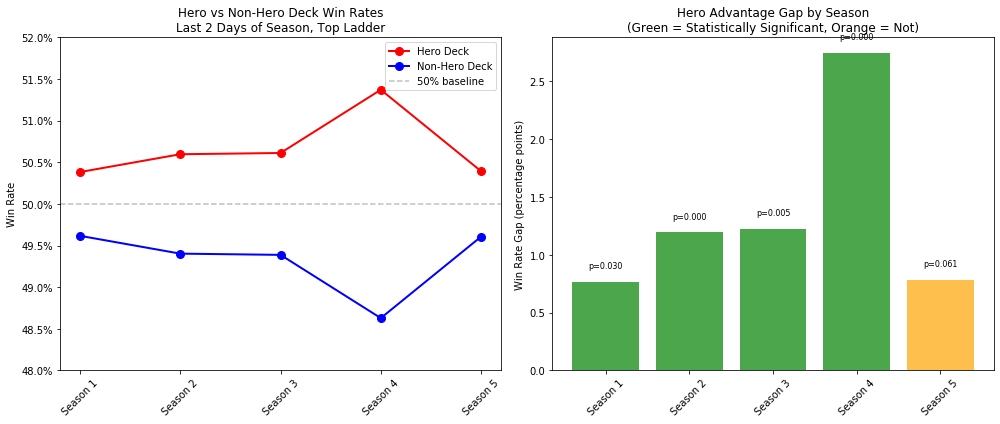

Figure saved to hero_winrate_analysis.png


In [17]:
# Plot hero vs non-hero win rates over seasons
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

seasons_list = results_df["season"].tolist()
x = range(len(seasons_list))

# Plot 1: Win rates comparison
ax1.plot(x, results_df["hero_winrate"], 
         marker="o", linewidth=2, markersize=8, 
         color="red", label="Hero Deck")
ax1.plot(x, results_df["nonhero_winrate"], 
         marker="o", linewidth=2, markersize=8, 
         color="blue", label="Non-Hero Deck")
ax1.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="50% baseline")
ax1.set_xticks(x)
ax1.set_xticklabels(seasons_list, rotation=45)
ax1.set_ylabel("Win Rate")
ax1.set_title("Hero vs Non-Hero Deck Win Rates\nLast 2 Days of Season, Top Ladder")
ax1.legend()
ax1.set_ylim(0.48, 0.52)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))

# Plot 2: Win rate gap over seasons
colors = ["green" if sig else "orange" 
          for sig in results_df["significant"]]
ax2.bar(x, results_df["winrate_gap"] * 100, color=colors, alpha=0.7)
ax2.set_xticks(x)
ax2.set_xticklabels(seasons_list, rotation=45)
ax2.set_ylabel("Win Rate Gap (percentage points)")
ax2.set_title("Hero Advantage Gap by Season\n(Green = Statistically Significant, Orange = Not)")
ax2.axhline(y=0, color="black", linewidth=0.5)

# Add significance markers
for i, (gap, sig, p) in enumerate(zip(results_df["winrate_gap"], 
                                       results_df["significant"], 
                                       results_df["p_value"])):
    ax2.text(i, gap * 100 + 0.1, 
             f"p={p:.3f}", 
             ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("hero_winrate_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to hero_winrate_analysis.png")

In [18]:
results_df.to_csv("hero_winrate_results.csv", index=False)
print("Results saved")

Results saved


In [19]:
# Hero usage rate per season
usage_results = []

for season in seasons.keys():
    season_df = df_filtered[df_filtered["season"] == season]
    if len(season_df) == 0:
        continue
    
    total_decks = len(season_df) * 2  # both p1 and p2
    hero_decks = season_df["p1_has_hero"].sum() + season_df["p2_has_hero"].sum()
    
    usage_rate = hero_decks / total_decks
    
    # Count which specific heroes are being used
    hero_counts = {}
    for hero_id in hero_ids:
        count = 0
        for player in [1, 2]:
            for i in range(8):
                id_col = f"p{player}_playing_card{i}_id"
                evo_col = f"p{player}_playing_card{i}_evolution_level"
                mask = (
                    (season_df[id_col] == hero_id) & 
                    (season_df[evo_col] == 2)
                )
                count += mask.sum()
        hero_counts[hero_id] = count
    
    # Most used hero this season
    most_used_id = max(hero_counts, key=hero_counts.get)
    most_used_name = {
        26000000: "Knight", 26000014: "Musketeer",
        26000003: "Giant", 26000018: "Mini PEKKA",
        26000017: "Wizard", 26000038: "Ice Golem",
        26000002: "Goblins", 26000039: "Mega Minion",
        26000062: "Magic Archer", 28000015: "Barbarian Barrel",
        26000006: "Balloon", 26000027: "Dark Prince",
        26000034: "Bowler", 27000009: "Tombstone"
    }.get(most_used_id, "Unknown")
    
    usage_results.append({
        "season": season,
        "hero_usage_rate": usage_rate,
        "total_decks_analyzed": total_decks,
        "hero_decks": hero_decks,
        "most_used_hero": most_used_name,
        "most_used_hero_count": hero_counts[most_used_id]
    })

usage_df = pd.DataFrame(usage_results)
print(usage_df.to_string(index=False))
usage_df.to_csv("hero_usage_results.csv", index=False)

   season  hero_usage_rate  total_decks_analyzed  hero_decks    most_used_hero  most_used_hero_count
 Season 1         0.579879                164562       95426        Mini PEKKA                 47450
 Season 2         0.551592                189080      104295        Mini PEKKA                 36752
 Season 3         0.770896                146104      112631           Goblins                 59011
 Season 4         0.856385                160714      137633      Magic Archer                 45689
 Season 5         0.806488                182412      147113  Barbarian Barrel                 33251


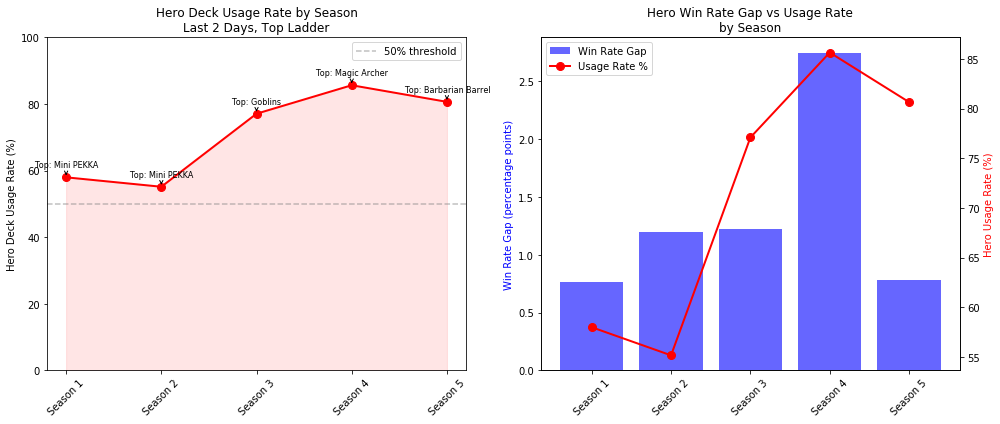

Figure saved


In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

seasons_list = usage_df["season"].tolist()
x = range(len(seasons_list))

# Plot 1: Hero usage rate over time
ax1.plot(x, usage_df["hero_usage_rate"] * 100,
         marker="o", linewidth=2, markersize=8,
         color="red")
ax1.fill_between(x, usage_df["hero_usage_rate"] * 100,
                 alpha=0.1, color="red")
ax1.set_xticks(x)
ax1.set_xticklabels(seasons_list, rotation=45)
ax1.set_ylabel("Hero Deck Usage Rate (%)")
ax1.set_title("Hero Deck Usage Rate by Season\nLast 2 Days, Top Ladder")
ax1.set_ylim(0, 100)
ax1.axhline(y=50, color="gray", linestyle="--", 
            alpha=0.5, label="50% threshold")
ax1.legend()

# Annotate most used hero
for i, (hero, rate) in enumerate(zip(usage_df["most_used_hero"],
                                      usage_df["hero_usage_rate"])):
    ax1.annotate(f"Top: {hero}",
                xy=(i, rate * 100),
                xytext=(i, rate * 100 + 3),
                ha="center", fontsize=8,
                arrowprops=dict(arrowstyle="->", color="black"))

# Plot 2: Combined win rate gap and usage
ax2_twin = ax2.twinx()

bars = ax2.bar(x, results_df["winrate_gap"] * 100,
               alpha=0.6, color="blue", label="Win Rate Gap")
line = ax2_twin.plot(x, usage_df["hero_usage_rate"] * 100,
                     marker="o", color="red", linewidth=2,
                     markersize=8, label="Usage Rate %")

ax2.set_xticks(x)
ax2.set_xticklabels(seasons_list, rotation=45)
ax2.set_ylabel("Win Rate Gap (percentage points)", color="blue")
ax2_twin.set_ylabel("Hero Usage Rate (%)", color="red")
ax2.set_title("Hero Win Rate Gap vs Usage Rate\nby Season")

# Combined legend
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig("hero_usage_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved")

In [21]:
# Vectorized individual hero win rates per season
hero_name_map = {
    26000000: "Knight", 26000014: "Musketeer",
    26000003: "Giant", 26000018: "Mini PEKKA",
    26000017: "Wizard", 26000038: "Ice Golem",
    26000002: "Goblins", 26000039: "Mega Minion",
    26000062: "Magic Archer", 28000015: "Barbarian Barrel",
    26000006: "Balloon", 26000027: "Dark Prince",
    26000034: "Bowler", 27000009: "Tombstone"
}

hero_season_stats = []

for season in seasons.keys():
    season_df = df_filtered[df_filtered["season"] == season].copy()
    if len(season_df) == 0:
        continue

    for hero_id, hero_name in hero_name_map.items():
        # Check all 8 slots vectorized for p1 and p2
        p1_has_this_hero = pd.Series(False, index=season_df.index)
        p2_has_this_hero = pd.Series(False, index=season_df.index)

        for i in range(8):
            p1_has_this_hero |= (
                (season_df[f"p1_playing_card{i}_id"] == hero_id) &
                (season_df[f"p1_playing_card{i}_evolution_level"] == 2)
            )
            p2_has_this_hero |= (
                (season_df[f"p2_playing_card{i}_id"] == hero_id) &
                (season_df[f"p2_playing_card{i}_evolution_level"] == 2)
            )

        # P1 using this hero
        p1_hero_games = season_df[p1_has_this_hero]
        p1_wins = p1_hero_games["p1_wins"].sum()
        p1_total = len(p1_hero_games)

        # P2 using this hero
        p2_hero_games = season_df[p2_has_this_hero]
        p2_wins = (~p2_hero_games["p1_wins"]).sum()
        p2_total = len(p2_hero_games)

        total = p1_total + p2_total
        wins = p1_wins + p2_wins

        if total >= 100:
            hero_season_stats.append({
                "season": season,
                "hero": hero_name,
                "wins": wins,
                "total_games": total,
                "win_rate": wins / total
            })

hero_stats_df = pd.DataFrame(hero_season_stats)

# Print results per season
for season in seasons.keys():
    season_stats = hero_stats_df[
        hero_stats_df["season"] == season
    ].sort_values("win_rate", ascending=False)
    if len(season_stats) == 0:
        continue
    print(f"\n{season} - Individual Hero Win Rates:")
    print(season_stats[["hero", "win_rate", "total_games"]].to_string(index=False))

hero_stats_df.to_csv("individual_hero_winrates.csv", index=False)
print("\nSaved to individual_hero_winrates.csv")


Season 1 - Individual Hero Win Rates:
       hero  win_rate  total_games
     Knight  0.508120        29373
  Musketeer  0.502064        22531
      Giant  0.499472        29369
 Mini PEKKA  0.497492        47450

Season 2 - Individual Hero Win Rates:
       hero  win_rate  total_games
     Wizard  0.509634         5553
  Ice Golem  0.507763        28854
 Mini PEKKA  0.501932        36752
  Musketeer  0.501901        10522
      Giant  0.501332        27782
     Knight  0.498851        33517

Season 3 - Individual Hero Win Rates:
        hero  win_rate  total_games
   Musketeer  0.511518         3603
      Knight  0.510417        30383
   Ice Golem  0.506763         9168
      Wizard  0.503028        14200
     Goblins  0.500856        59011
 Mega Minion  0.493676        20716
       Giant  0.491873         9413
  Mini PEKKA  0.487116        10168

Season 4 - Individual Hero Win Rates:
             hero  win_rate  total_games
          Goblins  0.508904        18251
      Mega Minion 

In [5]:
# Load top 100 player data
top100 = pd.read_csv(r"C:\Users\asawe\Documents\CR_Project\CR Finish Data - Sheet1.csv")
print(f"Total entries: {len(top100)}")
print(f"Seasons covered: {top100['season'].unique()}")
print(f"Columns: {list(top100.columns)}")
print(f"\nHero usage across all seasons:")
print(top100['has_hero'].value_counts())

Total entries: 600
Seasons covered: [1 2 3 4 5 6]
Columns: ['season', 'rank', 'player_tag', 'deck_name', 'has_hero', 'hero_used', 'rating']

Hero usage across all seasons:
Yes     469
No      130
Yes       1
Name: has_hero, dtype: int64


In [8]:
# Fix inconsistent capitalization
top100["has_hero"] = top100["has_hero"].str.strip().str.title()

# Verify fix
print("Hero usage after fix:")
print(top100["has_hero"].value_counts())

print("\nHero vs non-hero by season:")
print(top100.groupby(["season", "has_hero"])["player_tag"].count().unstack())

Hero usage after fix:
Yes    470
No     130
Name: has_hero, dtype: int64

Hero vs non-hero by season:
has_hero  No  Yes
season           
1         40   60
2         33   67
3         18   82
4          5   95
5         17   83
6         17   83


In [22]:
# Get list of top 100 player tags
top100_tags = top100["player_tag"].str.strip().tolist()
print(f"Total unique player tags: {len(set(top100_tags))}")

# Filter battle data to top 100 players only
# A game counts if either player is a top 100 finisher
df_elite = df_filtered[
    df_filtered["p1_tag"].isin(top100_tags) | 
    df_filtered["p2_tag"].isin(top100_tags)
].copy()

print(f"Games involving top 100 players: {len(df_elite)}")
print(f"\nGames per season:")
print(df_elite["season"].value_counts().sort_index())

Total unique player tags: 336
Games involving top 100 players: 143568

Games per season:
Season 1    29301
Season 2    34633
Season 3    23500
Season 4    27428
Season 5    28706
Name: season, dtype: int64


In [23]:
# Elite level hero vs non-hero win rates
elite_results = []

for season in seasons.keys():
    season_df = df_elite[df_elite["season"] == season].copy()
    if len(season_df) == 0:
        continue
    
    # Classify matchup types
    hero_vs_nonhero = season_df[
        season_df["p1_has_hero"] & ~season_df["p2_has_hero"]
    ]
    nonhero_vs_hero = season_df[
        ~season_df["p1_has_hero"] & season_df["p2_has_hero"]
    ]
    
    # Win rates
    hero_wins = (
        len(hero_vs_nonhero[hero_vs_nonhero["p1_wins"]]) +
        len(nonhero_vs_hero[~nonhero_vs_hero["p1_wins"]])
    )
    hero_total = len(hero_vs_nonhero) + len(nonhero_vs_hero)
    
    nonhero_wins = hero_total - hero_wins
    
    hero_winrate = hero_wins / hero_total if hero_total > 0 else None
    nonhero_winrate = nonhero_wins / hero_total if hero_total > 0 else None
    
    # T-test
    hero_outcomes = pd.concat([
        hero_vs_nonhero["p1_wins"].astype(int),
        (~nonhero_vs_hero["p1_wins"]).astype(int)
    ])
    nonhero_outcomes = pd.concat([
        nonhero_vs_hero["p1_wins"].astype(int),
        (~hero_vs_nonhero["p1_wins"]).astype(int)
    ])
    
    t_stat, p_value = stats.ttest_ind(hero_outcomes, nonhero_outcomes)
    
    elite_results.append({
        "season": season,
        "hero_winrate": hero_winrate,
        "nonhero_winrate": nonhero_winrate,
        "winrate_gap": hero_winrate - nonhero_winrate,
        "hero_vs_nonhero_games": hero_total,
        "t_statistic": t_stat,
        "p_value": p_value,
        "significant": p_value < 0.05
    })

elite_df = pd.DataFrame(elite_results)
print("Elite Level Results:")
print(elite_df.to_string(index=False))
elite_df.to_csv(r"C:\Users\asawe\Documents\CR_Project\elite_winrate_results.csv", index=False)

Elite Level Results:
   season  hero_winrate  nonhero_winrate  winrate_gap  hero_vs_nonhero_games  t_statistic   p_value  significant
 Season 1      0.514244         0.485756     0.028487                  14252     4.811319  0.000002         True
 Season 2      0.505412         0.494588     0.010824                  17091     2.001316  0.045366         True
 Season 3      0.518401         0.481599     0.036803                   6956     4.343484  0.000014         True
 Season 4      0.517236         0.482764     0.034472                   6440     3.914259  0.000091         True
 Season 5      0.506700         0.493300     0.013400                   8358     1.732586  0.083188        False


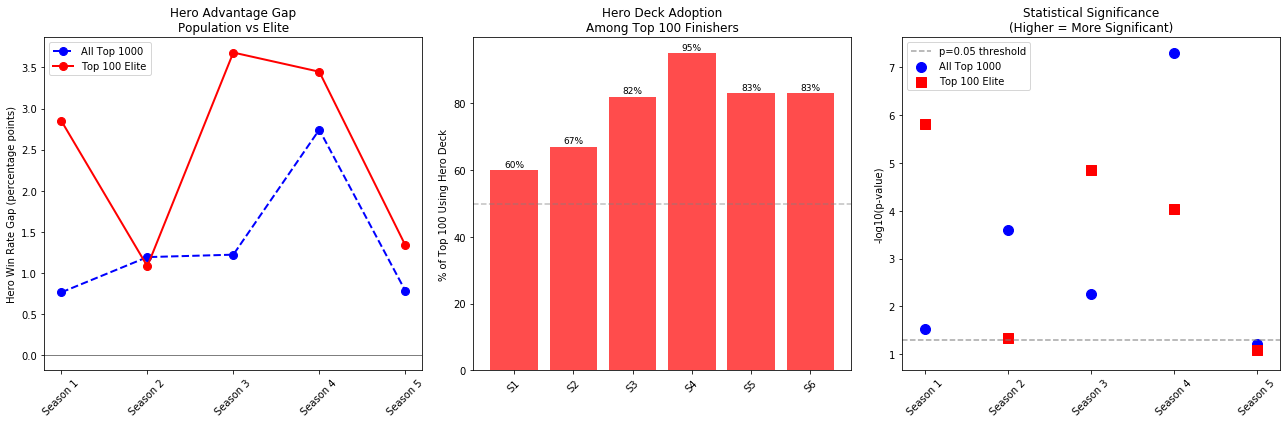

Figure saved


In [28]:
# Load population results for comparison
pop_df = pd.read_csv(r"C:\Users\asawe\CRProject\hero_winrate_results.csv")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

seasons_list = ["Season 1", "Season 2", "Season 3", "Season 4", "Season 5"]
x = range(len(seasons_list))

# Plot 1: Win rate gaps comparison
axes[0].plot(x, pop_df["winrate_gap"] * 100, 
             marker="o", linewidth=2, markersize=8,
             color="blue", label="All Top 1000", linestyle="--")
axes[0].plot(x, elite_df["winrate_gap"] * 100,
             marker="o", linewidth=2, markersize=8,
             color="red", label="Top 100 Elite")
axes[0].set_xticks(x)
axes[0].set_xticklabels(seasons_list, rotation=45)
axes[0].set_ylabel("Hero Win Rate Gap (percentage points)")
axes[0].set_title("Hero Advantage Gap\nPopulation vs Elite")
axes[0].legend()
axes[0].axhline(y=0, color="black", linewidth=0.5)

# Plot 2: Elite hero usage from top100 CSV
season_usage = top100.groupby("season")["has_hero"].apply(
    lambda x: (x == "Yes").sum()
).reset_index()
season_usage.columns = ["season", "hero_count"]
season_usage["hero_pct"] = season_usage["hero_count"] / 100 * 100

axes[1].bar(range(len(season_usage)), season_usage["hero_pct"],
            color="red", alpha=0.7)
axes[1].set_xticks(range(len(season_usage)))
axes[1].set_xticklabels([f"S{s}" for s in season_usage["season"]], rotation=45)
axes[1].set_ylabel("% of Top 100 Using Hero Deck")
axes[1].set_title("Hero Deck Adoption\nAmong Top 100 Finishers")
axes[1].axhline(y=50, color="gray", linestyle="--", alpha=0.5)
for i, pct in enumerate(season_usage["hero_pct"]):
    axes[1].text(i, pct + 1, f"{pct:.0f}%", ha="center", fontsize=9)

# Plot 3: P-values comparison
axes[2].scatter(x, [-np.log10(p) for p in pop_df["p_value"]],
                color="blue", s=100, label="All Top 1000", marker="o")
axes[2].scatter(x, [-np.log10(p) for p in elite_df["p_value"]],
                color="red", s=100, label="Top 100 Elite", marker="s")
axes[2].axhline(y=-np.log10(0.05), color="gray", linestyle="--",
                alpha=0.7, label="p=0.05 threshold")
axes[2].set_xticks(x)
axes[2].set_xticklabels(seasons_list, rotation=45)
axes[2].set_ylabel("-log10(p-value)")
axes[2].set_title("Statistical Significance\n(Higher = More Significant)")
axes[2].legend()

plt.tight_layout()
plt.savefig(r"C:\Users\asawe\CRProject\elite_vs_population_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved")

In [26]:
import os

# Check current working directory
print("Current directory:", os.getcwd())

# Search for the file
for root, dirs, files in os.walk(r"C:\Users\asawe"):
    for file in files:
        if "hero_winrate" in file.lower():
            print(os.path.join(root, file))

Current directory: C:\Users\asawe\CRProject
C:\Users\asawe\CRProject\hero_winrate_analysis.png
C:\Users\asawe\CRProject\hero_winrate_results.csv
C:\Users\asawe\CRProject\individual_hero_winrates.csv


In [27]:
import os

# List files in working directory
files = os.listdir(r"C:\Users\asawe\CRProject")
for f in files:
    print(f)

.ipynb_checkpoints
Code.ipynb
hero_usage_analysis.png
hero_usage_results.csv
hero_winrate_analysis.png
hero_winrate_results.csv
individual_hero_winrates.csv
Sentiment Analysis.ipynb


In [29]:
# Save elite results
elite_df.to_csv(r"C:\Users\asawe\CRProject\elite_winrate_results.csv", index=False)

# Print combined summary
print("=" * 70)
print("COMBINED SUMMARY: Population vs Elite Hero Deck Analysis")
print("=" * 70)

for i, season in enumerate(seasons_list):
    pop_row = pop_df[pop_df["season"] == season].iloc[0]
    elite_row = elite_df[elite_df["season"] == season].iloc[0]
    usage_pct = season_usage[season_usage["season"] == i+1]["hero_pct"].values[0]
    
    print(f"\n{season}:")
    print(f"  Hero usage (top 100):     {usage_pct:.0f}%")
    print(f"  Population win rate gap:  {pop_row['winrate_gap']*100:.2f}% (p={pop_row['p_value']:.4f})")
    print(f"  Elite win rate gap:       {elite_row['winrate_gap']*100:.2f}% (p={elite_row['p_value']:.4f})")
    print(f"  Elite gap > Pop gap:      {elite_row['winrate_gap'] > pop_row['winrate_gap']}")

COMBINED SUMMARY: Population vs Elite Hero Deck Analysis

Season 1:
  Hero usage (top 100):     60%
  Population win rate gap:  0.77% (p=0.0304)
  Elite win rate gap:       2.85% (p=0.0000)
  Elite gap > Pop gap:      True

Season 2:
  Hero usage (top 100):     67%
  Population win rate gap:  1.19% (p=0.0003)
  Elite win rate gap:       1.08% (p=0.0454)
  Elite gap > Pop gap:      False

Season 3:
  Hero usage (top 100):     82%
  Population win rate gap:  1.22% (p=0.0055)
  Elite win rate gap:       3.68% (p=0.0000)
  Elite gap > Pop gap:      True

Season 4:
  Hero usage (top 100):     95%
  Population win rate gap:  2.74% (p=0.0000)
  Elite win rate gap:       3.45% (p=0.0001)
  Elite gap > Pop gap:      True

Season 5:
  Hero usage (top 100):     83%
  Population win rate gap:  0.79% (p=0.0611)
  Elite win rate gap:       1.34% (p=0.0832)
  Elite gap > Pop gap:      True
